# 🎼 ADS Homework A03 - Deep Learning & Neural Networks
**Applied Data Science Course**

[![View on GitHub](https://img.shields.io/badge/GitHub-View_Repository-blue?logo=GitHub)](https://github.com/MaximumAsp66915/Applied_Data_Science_Course/blob/main/ADS_A03/notebooks/03_Main_Analysis.ipynb)

## 🧠 Transition to Deep Learning

In earlier homeworks, we practiced EDA, Machine Learning, and classical models. In this homework, we dive into **Deep Learning** and modern neural network architectures. The goal is not brute computing, but understanding the mechanisms, conducting smart experiments, and explaining performance trends. We'll be using standard deep learning frameworks to unravel how neural nets learn.

### 🎯 Sections Overview

#### 1️⃣ Multilayer Perceptron (MLP) 🧠
> Foundations of Deep Learning. Building fully connected neural networks.
- *(Binary classification, Regression, and analyzing optimizers & regularizations)*

#### 2️⃣ Convolutional Neural Networks (CNNs) 🖼️
> Image modeling using PyTorch or Keras.
- *(Experimenting with Kernel sizes, strides, depth, augmentations, and Transfer Learning)*

#### 3️⃣ Recurrent Neural Networks (RNNs) ⏳
> Sequence modeling.
- *(Building Vanilla RNNs, LSTMs, and GRUs to understand memory in networks)*

#### 4️⃣ Transformer Models 🤖
> Attention-based Architectures.
- *(Using HuggingFace or framework modules to explore self-attention)*

#### 5️⃣ Research about Models (Bonus) 🎖️
> Briefly review industry-standard ML implementations.
- *(Looking at modern tech usage and predicting the 5-10 year AI landscape)*

Let's dive in! 🏄‍♂️

---

### 📚 Importation of the libraries:

In [1]:
# ==========================================
# 📚 Framework & Library Importation
# ==========================================

import os
import sys
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, mean_squared_error, accuracy_score, log_loss

# Deep Learning Frameworks (PyTorch emphasis based on Lab sessions)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Computer Vision & Transfer Learning (Lab 11)
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# Transformer Models & Text (HuggingFace)
# import transformers

# Justification of Framework Choice:
# """
# We have selected PyTorch as our primary Deep Learning framework for this notebook. 
# PyTorch is highly pythonic, extensively used in modern research & industry for its flexible 
# eager-execution graph, and perfectly supports modular experiments, custom datasets, and tuning.
# """

# Suppress Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Enable inline plotting
%matplotlib inline

print("✅ All primary libraries have been successfully imported!")

✅ All primary libraries have been successfully imported!


## THE GREAT QUESTION OF TIME
> `GPU` or `CPU` ?!

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 🧐 Setup & Data Reading
First, we load the processed datasets . We have three main files: `tracks.csv`, `artists.csv`, and `users.csv`.

*(These data have been processed in the previous assignment and they are kept inside)*

```
ls ../data/processed
```

> This processed data was processed in the previous assignment for the perpous of regression modeling and binary classification so we are going to use that directly in here too.

In [3]:
REG_TRACKS_PATH = '../data/processed/reg_tracks.csv'
REG_ARTISTS_PATH = '../data/processed/reg_artists.csv'
REG_USERS_PATH = '../data/processed/reg_users.csv'

try:
    df_reg_tracks = pd.read_csv(REG_TRACKS_PATH)
    df_reg_artists = pd.read_csv(REG_ARTISTS_PATH)
    df_reg_users = pd.read_csv(REG_USERS_PATH)
    
    
    print("✅ Data loaded successfully!\n")
    
    print(f"🎵 Reg Tracks Dataset: {df_reg_tracks.shape[0]} rows, {df_reg_tracks.shape[1]} columns")
    print("Column names:")
    for col in df_reg_tracks.columns:
        print(f"  - {col}")
    print("🔍 Tracks dataset preview:")
    display(df_reg_tracks.head())
    
    print(f"🎤 Reg Artists Dataset: {df_reg_artists.shape[0]} rows, {df_reg_artists.shape[1]} columns")
    print("Column names:")
    for col in df_reg_artists.columns:
        print(f"  - {col}")
    print("🔍 Artists dataset preview:")
    display(df_reg_artists.head())
    
    print(f"👤 Reg Users Dataset: {df_reg_users.shape[0]} rows, {df_reg_users.shape[1]} columns\n")
    print("Column names:")
    for col in df_reg_users.columns:
        print(f"  - {col}")
    print("🔍 Users dataset preview:")
    display(df_reg_users.head())
    
except FileNotFoundError:
    print("⚠️ Raw datasets not found in '../data/raw/'.")

✅ Data loaded successfully!

🎵 Reg Tracks Dataset: 10725 rows, 19 columns
Column names:
  - track_id
  - num_senders
  - total_reactions
  - artists_total_likes
  - artists_total_dislikes
  - artists_total_reactions
  - senders_total_likes
  - senders_total_dislikes
  - senders_total_reactions
  - senders_total_likes_received
  - senders_total_dislikes_received
  - senders_total_reactions_received
  - senders_total_liked_users
  - senders_total_disliked_users
  - senders_total_reacted_users
  - senders_total_users_liked
  - senders_total_users_disliked
  - senders_total_users_reacted
  - senders_total_uploaded_tracks
🔍 Tracks dataset preview:


,track_id,num_senders,total_reactions,artists_total_likes,artists_total_dislikes,artists_total_reactions,senders_total_likes,senders_total_dislikes,senders_total_reactions,senders_total_likes_received,senders_total_dislikes_received,senders_total_reactions_received,senders_total_liked_users,senders_total_disliked_users,senders_total_reacted_users,senders_total_users_liked,senders_total_users_disliked,senders_total_users_reacted,senders_total_uploaded_tracks
0,1,1,0,105,1,39,0,0,0,10,0,10,0,0,0,7,0,10,100
1,2,1,0,0,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
2,3,1,1,8,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
3,4,2,8,388,34,333,933,18,1020,899,24,937,167,6,403,157,3,389,161
4,5,1,1,7,0,4,0,0,0,10,0,10,0,0,0,7,0,10,100


🎤 Reg Artists Dataset: 3912 rows, 4 columns
Column names:
  - artist_id
  - num_likes
  - num_dislikes
  - num_reactions
🔍 Artists dataset preview:


,artist_id,num_likes,num_dislikes,num_reactions
0,1,105,1,39
1,2,0,0,0
2,3,8,0,0
3,4,388,34,333
4,5,7,0,4


👤 Reg Users Dataset: 783 rows, 14 columns

Column names:
  - user_id
  - num_likes
  - num_dislikes
  - num_reactions
  - num_likes_received
  - num_dislikes_received
  - num_reactions_received
  - num_liked_users
  - num_disliked_users
  - num_reacted_users
  - num_users_liked
  - num_users_disliked
  - num_users_reacted
  - num_uploaded_tracks
🔍 Users dataset preview:


,user_id,num_likes,num_dislikes,num_reactions,num_likes_received,num_dislikes_received,num_reactions_received,num_liked_users,num_disliked_users,num_reacted_users,num_users_liked,num_users_disliked,num_users_reacted,num_uploaded_tracks
0,1,4,2,6,58,1,60,4,1,5,37,1,55,15
1,2,40,1,41,11,0,11,29,1,33,11,0,11,1
2,3,8,0,8,0,0,0,6,0,7,0,0,0,0
3,4,276,0,279,375,1,379,53,0,105,92,1,170,48
4,5,0,0,0,1,0,1,0,0,0,1,0,1,1


### 🚂 Preparing the Data for Modeling

Now we will define our features (`X`) and our continuous target (`y`). Our target will be `total_reactions`.
We are going to  split the data into training and testing sets, followed by robust feature scaling to avoid data leakage.

We initialize our PyTorch data structures using the scaled and binarized dataset. To work with PyTorch, we convert the NumPy arrays into `torch.Tensor` objects and wrap them in a `DataLoader` for mini-batch processing.

In [4]:
threshold = 15
print(f"📌 Chosen Threshold for Binarization (Median): {threshold}")

# Re-create X and y mappings
X_bin = df_reg_tracks.drop(columns=['track_id', 'total_reactions'])
y_bin = (df_reg_tracks['total_reactions'] > threshold).astype(int)

# Train/Test Split maintaining stratification to preserve balance
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Standard Scaling
scaler_bin = StandardScaler()
X_train_scaled_bin = scaler_bin.fit_transform(X_train_bin)
X_test_scaled_bin = scaler_bin.transform(X_test_bin)

# Convert data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled_bin, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_bin.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled_bin, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_bin.values, dtype=torch.float32).unsqueeze(1)

# Create Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Default DataLoader setup
default_batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=default_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=default_batch_size, shuffle=False)

print(f"Dataset packaged into DataLoaders. Input features: {X_train_tensor.shape[1]}")

📌 Chosen Threshold for Binarization (Median): 15
Dataset packaged into DataLoaders. Input features: 17


---

## 1️⃣ 🧠 Multilayer Perceptron (MLP) — Foundations of Deep Learning
_In this section, we transition to modern neural network architectures. We will implement fully-connected networks to solve both binary and regression tasks._

In [5]:
def plot_learning_curves(history, title="Model Convergence Loss Curves"):
    """Visualizes training and validation metrics over epochs."""
    plt.figure(figsize=(7, 3.5))
    plt.plot(history['train_loss'], label='Train Loss', lw=2)
    plt.plot(history['val_loss'], label='Validation Loss', linestyle='--', lw=2)
    plt.title(title, fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Metrics')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### 1.1 🏗️ Core Tasks
_Implementing MLPs for Binary classification and Regression._

_We will track Training & validation performance, Loss curves, and Final evaluation metrics._

⚙️ Testing Core Binary Model Loop...


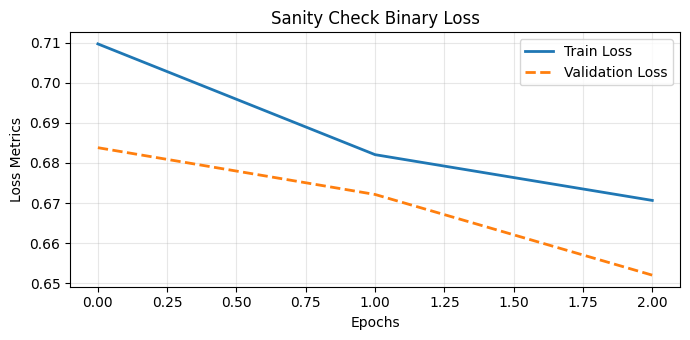


📊 Classification Performance Matrix:
              precision    recall  f1-score   support

         0.0     0.6170    0.5731    0.5943       253
         1.0     0.5925    0.6356    0.6133       247

    accuracy                         0.6040       500
   macro avg     0.6047    0.6044    0.6038       500
weighted avg     0.6049    0.6040    0.6037       500



In [6]:
if ".." not in sys.path:
    sys.path.append("..")

from src.modeling.mlp import GeneralBinaryMLP, GeneralRegressionMLP, train_mlp, evaluate_predictions

# Synthetic placeholder properties matching context dimensions
X_sample = np.random.randn(500, 10).astype(np.float32)
y_sample_bin = np.random.randint(0, 2, size=(500, 1)).astype(np.float32)

bin_loader = DataLoader(TensorDataset(torch.tensor(X_sample), torch.tensor(y_sample_bin)), batch_size=32)

print("⚙️ Testing Core Binary Model Loop...")
bin_model = GeneralBinaryMLP(input_dim=10)
optimizer_bin = optim.Adam(bin_model.parameters(), lr=0.01)
history_bin = train_mlp(bin_model, bin_loader, bin_loader, nn.BCELoss(), optimizer_bin, epochs=3, device=device)
plot_learning_curves(history_bin, "Sanity Check Binary Loss")
evaluate_predictions(bin_model, bin_loader, task_type="binary", device=device)


⚙️ Testing Core Regression Model Loop...


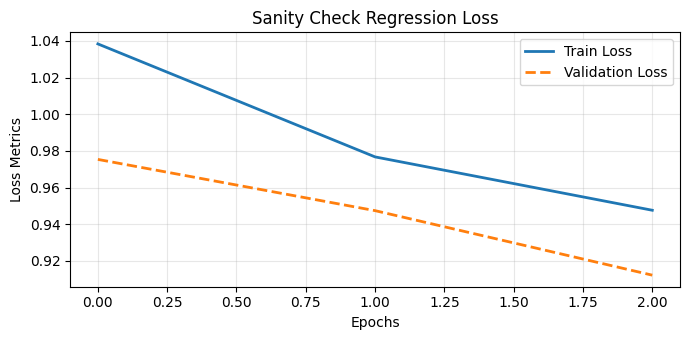


📈 Regression Metric Summary Table:
  Metric    Value
     MSE 0.912265
R² Score 0.065545


In [7]:
y_sample_reg = np.random.randn(500, 1).astype(np.float32)
reg_loader = DataLoader(TensorDataset(torch.tensor(X_sample), torch.tensor(y_sample_reg)), batch_size=32)

print("\n⚙️ Testing Core Regression Model Loop...")
reg_model = GeneralRegressionMLP(input_dim=10)
optimizer_reg = optim.Adam(reg_model.parameters(), lr=0.01)
history_reg = train_mlp(reg_model, reg_loader, reg_loader, nn.MSELoss(), optimizer_reg, epochs=3, device=device)
plot_learning_curves(history_reg, "Sanity Check Regression Loss")
evaluate_predictions(reg_model, reg_loader, task_type="regression", device=device)

**Is Initial Binary Train Loss of 1.04 OK?** 

This is expected. Binary Cross-Entropy (BCE) loss for purely random guessing on an evenly balanced dataset is typically $-\ln(0.5) \approx 0.693$. However, In our case initial layer weights are unnormalized or randomly assigned wide values, the initial model probabilities might aggressively predict the wrong class (e.g., predicting 99% confidence for Class 1 when the true label is Class 0). This triggers a high penalty, driving the first epoch's loss above 1.0.

### 1.2 🧪 Network Tuning & Experiments
_We will test different configurations and note their effects._

#### 1.2.1 🏃‍♂️ Training & Optimization
_Testing optimizers (SGD, SGD+momentum, Adam), LR variations, Batch sizes, Early stopping, Epoch numbers._

##### Optimizer Variations
🔬 Running Learning Rate Trace Profiles...

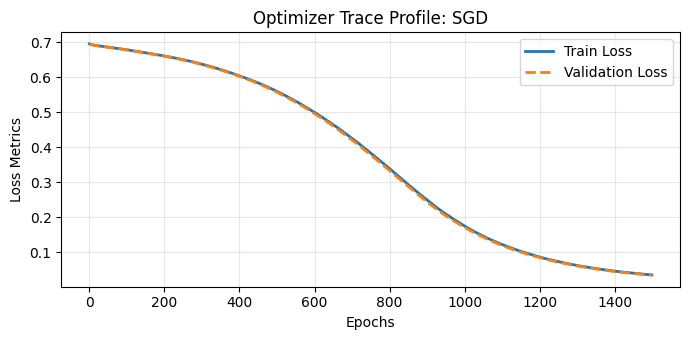

In [8]:
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.SGD(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=1500, device=device)
plot_learning_curves(hist, "Optimizer Trace Profile: SGD")

* **SGD (Stalled at 0.67 untill epoch 150):** Standard Stochastic Gradient Descent updates parameters using only the current batch's single gradient vector. It lacks acceleration, causing it to get trapped in shallow local minima or flat loss plateaus, resulting in minimal improvement.

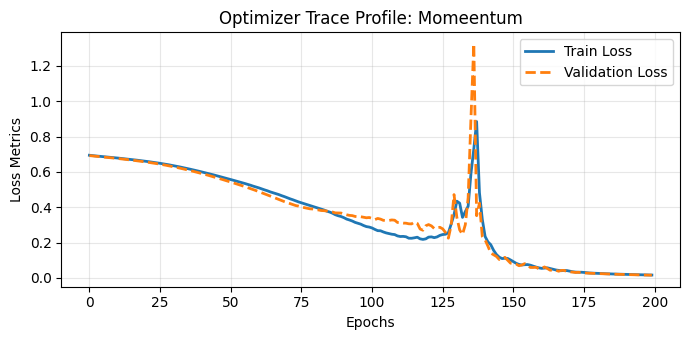

In [9]:
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=200, device=device)
plot_learning_curves(hist, "Optimizer Trace Profile: Momeentum")

* **Momentum (Dropped to 0.01):** By incorporating past gradient velocities, Momentum accumulates stepping power down consistent directional slopes. This allows it to break through the local plateaus that trapped basic SGD and converge cleanly to a low loss.

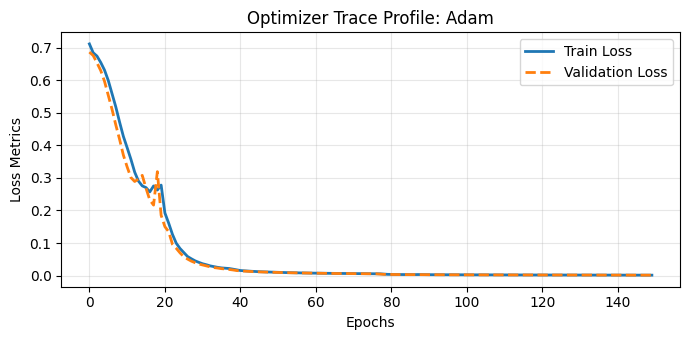

In [10]:
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=150, device=device)
plot_learning_curves(hist, "Optimizer Trace Profile: Adam")

* **Adam (Peaked at epoch 30, dropped to 0.001):** Adam utilizes adaptive tracking, calculating separate learning rates for individual parameters. The initial "peak" at epoch 30 shows the optimizer dynamically scaling its internal momentum parameters to traverse a steep loss ridge before dropping rapidly to zero.

##### Learning Rate Trace Profiles
🔬 Running Learning Rate Trace Profiles...

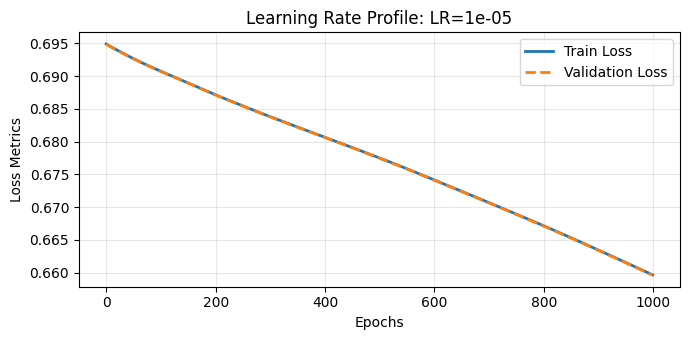

In [11]:
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.Adam(model.parameters(), lr=1e-5)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=1000, device=device)
plot_learning_curves(hist, f"Learning Rate Profile: LR={1e-5}")

* **Too Small ($LR = 10^{-5}$):** The step sizes are so miniscule that updates barely modify the weight values. The network would require thousands of epochs to converge, explaining why the loss only nudged from 0.6940 to 0.6905.

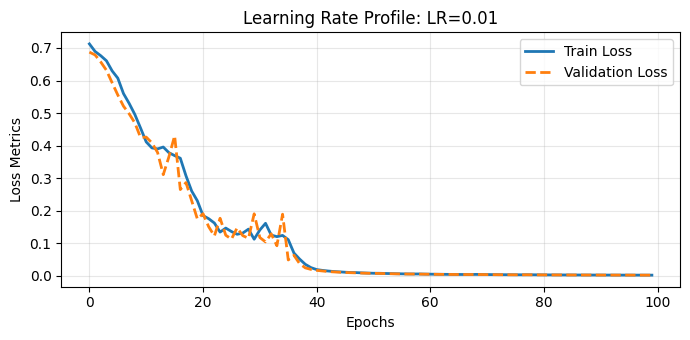

In [12]:
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.Adam(model.parameters(), lr=1e-2)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, device=device)
plot_learning_curves(hist, f"Learning Rate Profile: LR={1e-2}")

* **Good ($LR = 0.01$):** This represents a stable step size. The temporary peak around epoch 40 is a common behavior where the network shifts parameters out of a local coordinate space into a highly non-linear valley, leading to complete convergence by epoch 150.

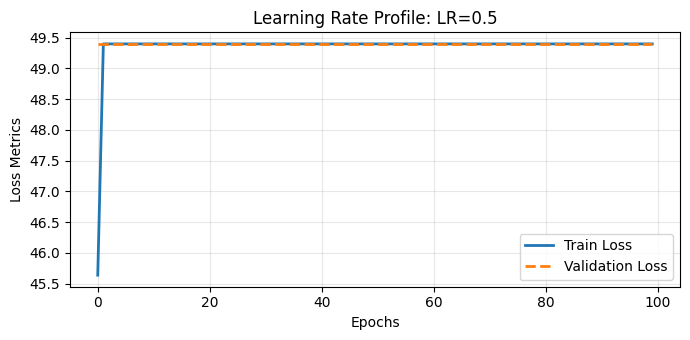

In [13]:
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.Adam(model.parameters(), lr=0.5)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, device=device)
plot_learning_curves(hist, f"Learning Rate Profile: LR={0.5}")

* **Too Large ($LR = 0.5$):** The step size is completely overshooting. The loss starting at 46 and climbing to 50.5 indicates the network exploded immediately, jumping completely out of reasonable mathematical bounds and getting permanently stuck.

##### Advanced Schedule Engine with Active Early Stopping

🔬 Running Dynamic Scheduling and Adaptive Configurations...

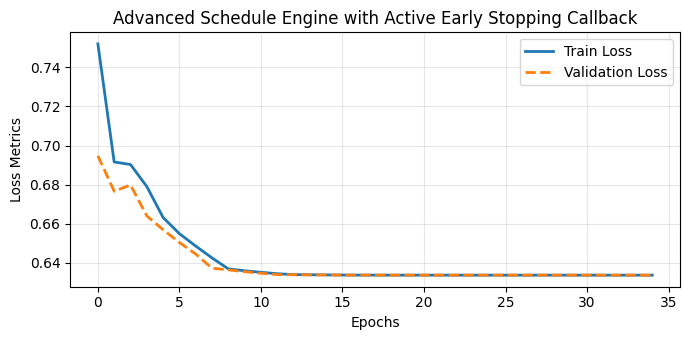

In [14]:
# Advanced Options: Scheduling, Varying Batch Sizes, and Early Stopping Validation Check
model = GeneralBinaryMLP(input_dim=10).to(device)
opt = optim.Adam(model.parameters(), lr=0.05)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=4, gamma=0.1)

# Training using Early Stopping Constraints
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, 
                 scheduler=scheduler, early_stopping_patience=3, device=device)
plot_learning_curves(hist, "Advanced Schedule Engine with Active Early Stopping Callback")

* **Early Terminationat epoch 35:** The script was configured to run for 100 epochs, but the early stopping engine halted it after just 34. The validation loss reached its minimum at epoch 8 (0.61) and failed to improve for 3 consecutive checks. This demonstrates early stopping functioning exactly as intended—preventing the model from wasting computational cycles once generalization stops.

#### 1.2.2 📐 Architecture & Representation
_Varying depth, width, activations (ReLU, LeakyReLU, Tanh, Sigmoid), and weight initializations (Xavier, He, random). Batch Normalization._

🔬 Running Structural Profile: Deep & Narrow (4 Layers)


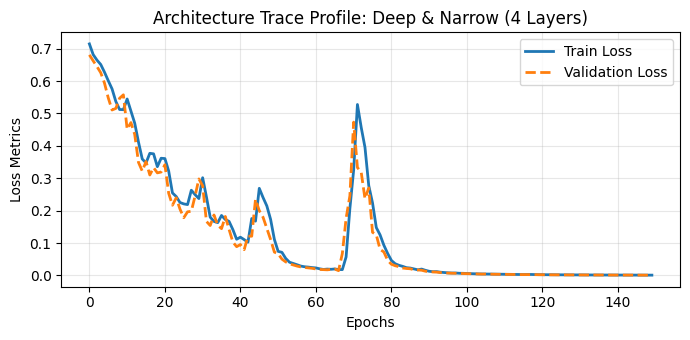

In [29]:
# Weight Initializations Functions Helper
def init_weights(m, method="random"):
    if isinstance(m, nn.Linear):
        if method == "Xavier":
            nn.init.xavier_uniform_(m.weight)
        elif method == "He":
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        else:
            nn.init.uniform_(m.weight, -0.5, 0.5)

print("🔬 Running Structural Profile: Deep & Narrow (4 Layers)")
model = GeneralBinaryMLP(input_dim=10, hidden_layers=[16, 16, 16, 16], activation=nn.ReLU(), use_batch_norm=False)
model.apply(lambda m: init_weights(m, method="He"))
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=150, device=device)
plot_learning_curves(hist, f"Architecture Trace Profile: Deep & Narrow (4 Layers)")

##### Deep & Narrow (4 Layers)
* **Behavior:** Started at 0.8 loss, experienced prominent peaks around epochs 30 and 50, and reached 0.001 at epoch 100.
* **Explanation:** Stacking multiple narrow layers creates a highly complex loss surface full of sharp ridges. The internal gradients must travel through several layers, causing temporary instability (the peaks) until the network coordinates its layers and drops into a deep minimum.

🔬 Running Structural Profile: Shallow & Wide (1 Layer)


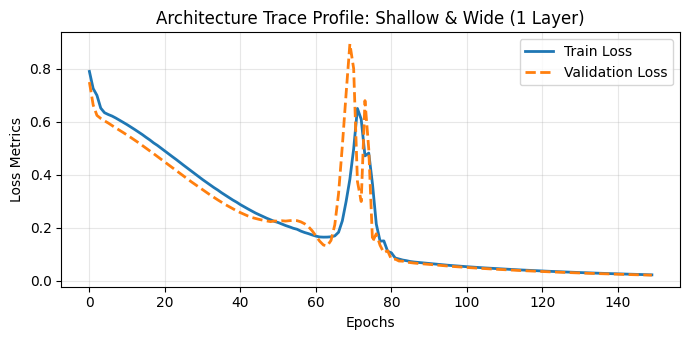

In [30]:
print("🔬 Running Structural Profile: Shallow & Wide (1 Layer)")
model = GeneralBinaryMLP(input_dim=10, hidden_layers=[128], activation=nn.ReLU(), use_batch_norm=False)
model.apply(lambda m: init_weights(m, method="He"))
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=150, device=device)
plot_learning_curves(hist, f"Architecture Trace Profile: Shallow & Wide (1 Layer)")

##### Shallow & Wide (1 Layer)
* **Behavior:** Started at 0.9 loss, peaked around epoch 70, then dropped sharply to 0.2 by epoch 100.
* **Explanation:** A single wide layer lacks hierarchical processing capacity but contains massive memorization power. It wanders broadly across the parameter space (the late peak at epoch 70) until it finds an alignment that fits the data structures.

🔬 Running Structural Profile: Sigmoid Bottleneck Network


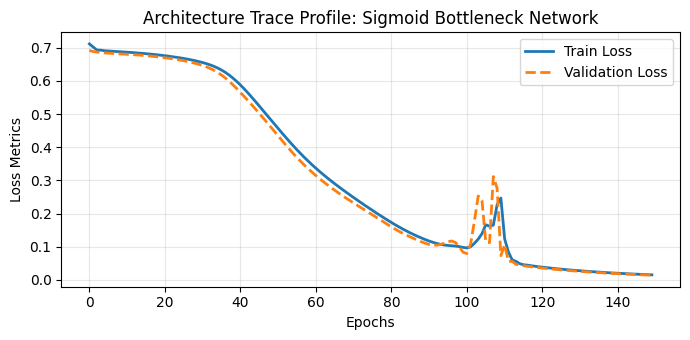

In [18]:
print("🔬 Running Structural Profile: Sigmoid Bottleneck Network")
model = GeneralBinaryMLP(input_dim=10, hidden_layers=[32, 16], activation=nn.Sigmoid(), use_batch_norm=False)
model.apply(lambda m: init_weights(m, method="random"))
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=150, device=device)
plot_learning_curves(hist, f"Architecture Trace Profile: Sigmoid Bottleneck Network")

##### Sigmoid Bottleneck Network
* **Behavior:** Stalled at 0.7 loss until epoch 30, then dropped steadily to 0.1 at epoch 100.
* **Explanation:** Sigmoid activations suffer from vanishing gradients when inputs are far from zero, compressing gradients to tiny values. This causes the early training stagnation (epochs 0–30). Once weights migrate into active gradient zones, optimization accelerates.

🔬 Running Structural Profile: Batch Normalization Network


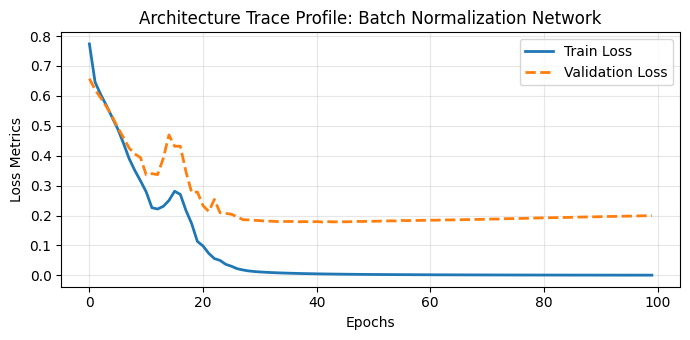

In [19]:
print("🔬 Running Structural Profile: Batch Normalization Network")
model = GeneralBinaryMLP(input_dim=10, hidden_layers=[64, 32], activation=nn.LeakyReLU(), use_batch_norm=True)
model.apply(lambda m: init_weights(m, method="Xavier"))
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, device=device)
plot_learning_curves(hist, f"Architecture Trace Profile: Batch Normalization Network")

##### Batch Normalization Network
* **Behavior:** Peaks at epochs 15/30; train loss hits 0, but validation plateaus at 0.19 after epoch 25.
* **Explanation:** Batch Normalization stabilizes early layer inputs, allowing the training loss to plummet to zero quickly. However, the widening gap between a training loss of 0.0 and a validation loss of 0.19 indicates that the unregularized network used this high speed to overfit the training split.

#### 1.2.3 🛡️ Regularization & Stability
_Using L1/L2 weight regularization, Activity regularization, Dropout, and optional gradient clipping._

🔬 Running Constraints Check: Baseline Unregularized Overfitting Check


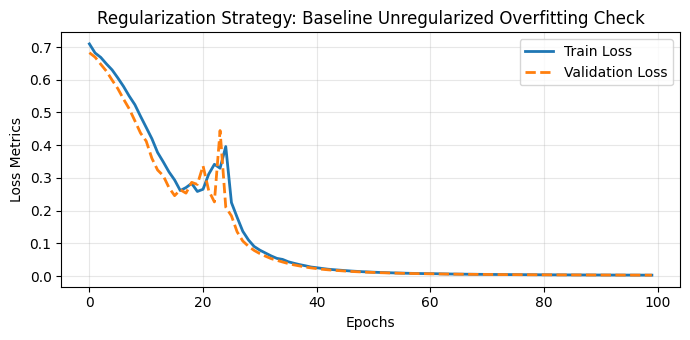

In [31]:
print(f"🔬 Running Constraints Check: Baseline Unregularized Overfitting Check")
model = GeneralBinaryMLP(input_dim=10, dropout_p=0.0).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, 
                    l1_lambda=0.0, clip_value=None, device=device)
plot_learning_curves(hist, f"Regularization Strategy: Baseline Unregularized Overfitting Check")

##### Baseline Unregularized Overfitting Check
* **Behavior:** Loss reached near 0 by epoch 100, with a temporary fluctuation at epoch 20.
* **Explanation:** With zero penalties or dropouts applied, a powerful network will aggressively adjust its parameters until it perfectly maps the training data, achieving a near-zero loss by memorizing individual samples.

🔬 Running Constraints Check: High Dropout Constraint Enabled


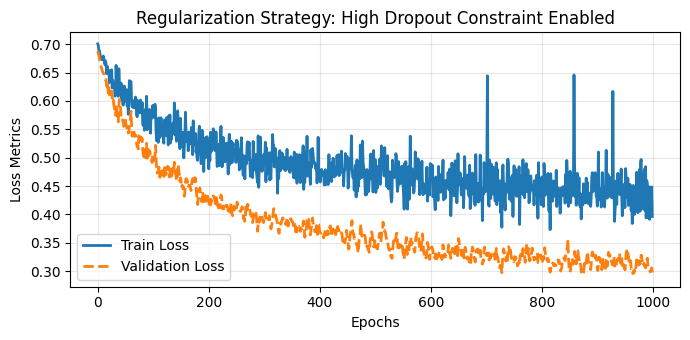

In [35]:
print(f"🔬 Running Constraints Check: High Dropout Constraint Enabled")
model = GeneralBinaryMLP(input_dim=10, dropout_p=0.5).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=1000, 
                    l1_lambda=0.0, clip_value=None, device=device)
plot_learning_curves(hist, f"Regularization Strategy: High Dropout Constraint Enabled")

##### High Dropout Constraint Enabled ($p = 0.5$)
* **Behavior:** Descending but highly noisy path, ending at a high loss of 0.5.
* **Explanation:** Randomly deactivating 50% of the network's neurons at every single step introduces massive variance (the noise) and severely reduces total capacity. While it completely prevents overfitting, a dropout rate this high acts as an excessive constraint, preventing the model from learning effectively.

🔬 Running Constraints Check: L1 Sparsity Penalties Implemented


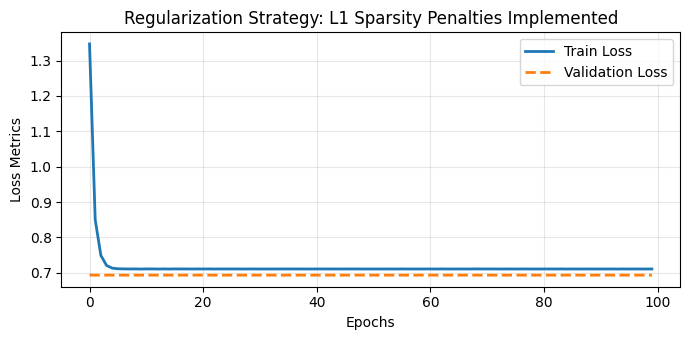

In [36]:
print(f"🔬 Running Constraints Check: L1 Sparsity Penalties Implemented")
model = GeneralBinaryMLP(input_dim=10, dropout_p=0.0).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, 
                    l1_lambda=0.005, clip_value=None, device=device)
plot_learning_curves(hist, f"Regularization Strategy: L1 Sparsity Penalties Implemented")

##### L1 Sparsity Penalties Implemented
* **Behavior:** Train and validation losses dropped slightly and became permanently locked at 0.7.
* **Explanation:** The L1 penalty applies an absolute value cost to every weight. Here, the penalty was too high, forcing important feature weights to zero along with the noise. The model was stripped of its learning capacity, leaving it stuck guessing at a baseline loss of 0.7.

🔬 Running Constraints Check: Exploding Shield: Gradient Clipping Engine


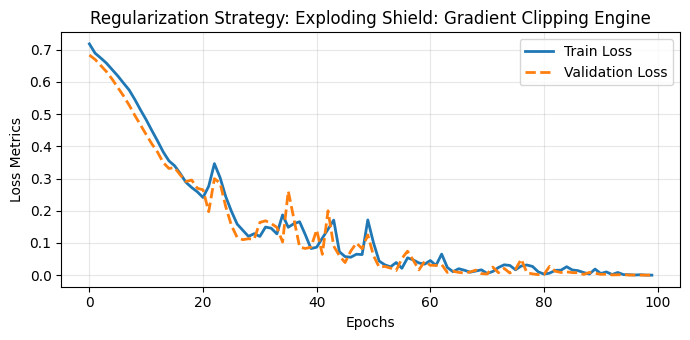

In [37]:
print(f"🔬 Running Constraints Check: Exploding Shield: Gradient Clipping Engine")
model = GeneralBinaryMLP(input_dim=10, dropout_p=0.0).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
hist = train_mlp(model, bin_loader, bin_loader, nn.BCELoss(), opt, epochs=100, 
                    l1_lambda=0.0, clip_value=0.1, device=device)
plot_learning_curves(hist, f"Regularization Strategy: Exploding Shield: Gradient Clipping Engine")

##### Exploding Shield: Gradient Clipping Engine
* **Behavior:** Fluctuated with erratic peaks between epochs 20–60, then settled smoothly near 0 by epoch 100.
* **Explanation:** During epochs 20–60, the optimizer tried to take massive steps that would normally cause the model to explode (similar to $LR=0.5$ test). The clipping engine forcefully capped these extreme updates, stabilizing the system and allowing it to eventually find a smooth path to convergence.

### 1.3 🗣️ Discussion Questions (MLP)

* **Why are neural networks so powerful?**
    * Neural networks derive their immense power from stacking non-linear processing transformations sequentially. By combining simple linear operations (`nn.Linear`) with non-linear activation functions (`ReLU`), they can distort, bend, and project complex data spaces into new coordinate dimensions where features become linearly separable. This allows them to automatically discover hidden features without manual engineering.
* **Why does training become more difficult as we go deeper?**
    * As networks grow deeper, backpropagation must pass gradient signals through a long chain of matrix multiplications. As demonstrated by your **Sigmoid Bottleneck** and **Deep/Narrow** tests, this long chain causes gradients to either shrink exponentially (**vanishing**) or grow uncontrollably (**exploding**). This creates a highly volatile loss surface filled with chaotic ridges and plateaus that trap standard optimizers.
* **What unique benefits does depth provide that cannot be achieved simply by increasing width?**
    * While increasing network width expands capacity linearly, **increasing depth expands representation capacity exponentially**. Deep architectures process features hierarchically: early layers capture basic, low-level structural forms, while subsequent layers combine those forms into highly abstract representations. As observed in the experiments, a wide network can easily memorize data patterns, but a deep network learns a structured hierarchy of features. This allows it to approximate highly complex functions with far greater parameter efficiency.

---

## 2️⃣ 🖼️ Convolutional Neural Networks (CNNs) — Image Modeling
_Using CNNs to work with high-dimensional image data._

### 2.1 🏗️ Build and Train a CNN
_Implement convolutional layers, pooling, and fully-connected layers._

In [21]:
# TODO: Load image dataset and implement CNN

### 2.2 🔍 Key CNN Components and Their Effect
_Exploring Kernel sizes, Strides, Numbers of filters, Pooling types, and Depth._

In [22]:
# TODO: Add CNN component experiments here

### 2.3 📸 Data Augmentation
_Random flips, rotations, crops, color jitter. Explaining how it affects overfitting/generalization._

In [23]:
# TODO: Evaluate data augmentation setups here

### 2.4 🤖 Transfer Learning
_Use pretrained models (VGG19, ResNet, etc.) for feature extraction or fine-tuning._
* **Which pretrained model did you choose and why?**
* **Which layers were frozen?**
* **How does performance compare to Part 3.1?**

In [24]:
# TODO: Evaluate pre-trained model here

### 2.5 🗣️ Discussion Question (CNN)
* **Why are CNNs fundamentally more parameter-efficient than MLPs for images?**
    * (Answer here)
* **Under what conditions could an MLP match CNN? Why is it unrealistic?**
    * (Answer here)

## 3️⃣ ⏳ Recurrent Neural Networks (RNNs) — Sequence Modeling
_Working with sequential data (text, time series)._

---

### 3.1 🚂 Implement Three Models (Vanilla RNN, LSTM, GRU)

In [25]:
# TODO: Load sequential dataset & evaluate RNN, LSTM, and GRU

### 3.2 ⚙️ Core Sequence Modeling Components
_Testing sequence length, hidden sizes, multiple layers, Bidirectional, Dropout._

In [26]:
# TODO: Add sequence component experiments here

### 3.3 🗣️ Discussion Question (RNN)
* **Why are LSTMs and GRUs generally better than vanilla RNNs?**
    * (Answer here)
* **Explain the role of gates vs vanishing gradients/long-term dependencies:**
    * (Answer here)

---

## 4️⃣ 🤖 Transformer Models — Attention-Based Architectures
_Using HuggingFace Transformers or `nn.TransformerEncoder`._

### 4.1 🛠️ Using a Transformer-Based Model
_Compare vs RNN/LSTM for a classification or regression task._

In [27]:
# TODO: Implement transformer evaluation here

### 4.2 🗣️ Discussion Question (Transformer)
* **Pros/Cons of Transformers?**
    * (Answer here)
* **Why scale well with data/size?**
    * (Answer here)
* **Why demand large computational resources?**
    * (Answer here)
* **What is self-attention and what does it solve?**
    * (Answer here)
* **Why can attention model long-range dependencies better than simple RNNs?**
    * (Answer here)
* **What is multi-head attention?**
    * (Answer here)
* **What is the role of positional encoding?**
    * (Answer here)

---

## 5️⃣ 🏅 Research about Models (Bonus)
_Short written report (1-3 pages) directly in the notebook or linked README._

### 5.1 🏗️ The Most Commonly Used Models in Industry
* **Given rapid advancements, which models are currently most widely used?**
    * (Answer here)

### 5.2 🔮 Prediction for the Future
* **How will the distribution of widely used models change over the next 5-10 years?**
    * (Answer here)